### Setup and Mode Configuration
Imports core paths and configures the default execution mode (live vs. cache).


In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from mnn_torch import paths

# Default mode computes reduced-budget live data. Set to "full_sweep_cache" only
# to render committed publication-scale arrays generated by heavy sweeps.
RESULT_MODE = "live"
if RESULT_MODE not in {"live", "full_sweep_cache"}:
    raise ValueError("RESULT_MODE must be 'live' or 'full_sweep_cache'")

RES = str(paths.results_dir() / "temporal")
SR = str(paths.results_dir() / "storerecall")

LIVE_SEEDS = (0, 1, 2)
LIVE_N_TRAIN = 180
LIVE_N_TEST = 120
LIVE_CLASS_SEPARABILITY = True
LIVE_CLASS_TRAIN_N = 384
LIVE_CLASS_TEST_N = 240
LIVE_DEVICE = "cuda"

TEAL = "#3aa07a"; RED = "#c0392b"; BLUE = "#2f4b8f"; GREY = "#9aa6b2"; AMBER = "#e0a93b"
INDIGO = "#5b6fb0"; INK = "#2b2b2b"


def boot_ci(v, n=2000, seed=0):
    v = np.asarray(v, float); rng = np.random.default_rng(seed)
    b = [v[rng.integers(0, len(v), len(v))].mean() for _ in range(n)]
    return np.percentile(b, 2.5), np.percentile(b, 97.5)


def _load_full_grid(path, *, panel):
    if RESULT_MODE != "full_sweep_cache":
        raise RuntimeError("Full-sweep cache requested from a live-mode cell")
    z = np.load(path, allow_pickle=True).item()
    print(f"FULL-SWEEP CACHE for {panel}: {z.get('source', path)}")
    return z


print("RESULT_MODE:", RESULT_MODE)
print("data/results:", paths.results_dir())

RESULT_MODE: live
data/results: C:\Users\User\git\mnn-torch\data\results


### Temporal-memory result modes

`RESULT_MODE = "live"` recomputes reduced-budget temporal probes in the notebook. `RESULT_MODE = "full_sweep_cache"` renders committed publication-scale `.npy` outputs and prints their provenance. The final cell leaves the cache-regeneration command pattern commented for examiners who want to run heavier sweeps.

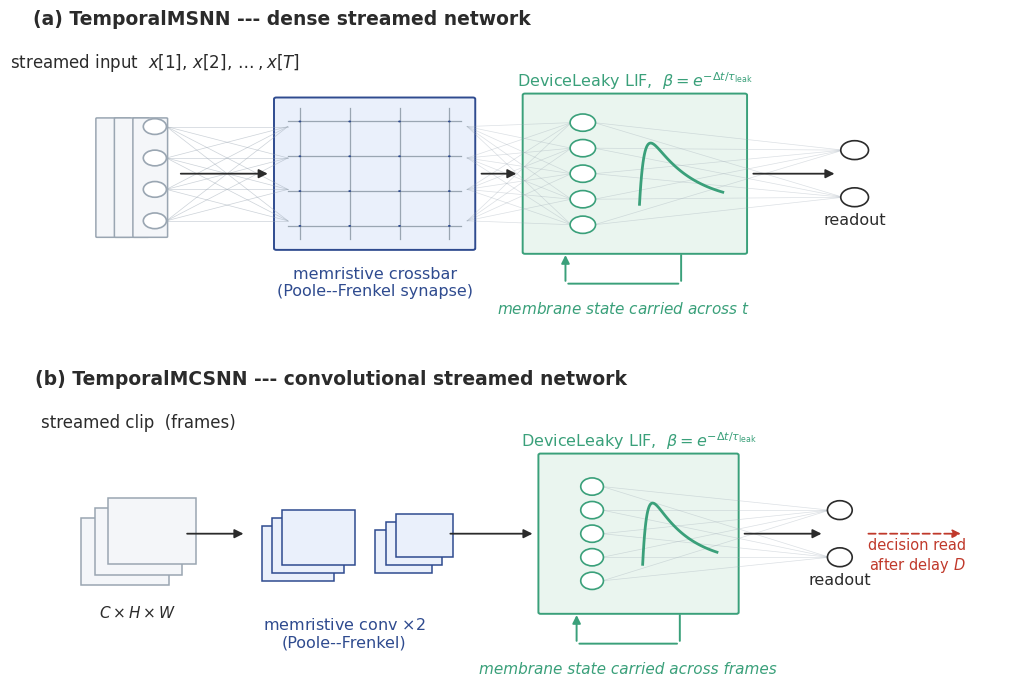

In [2]:
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch, Rectangle
from matplotlib.lines import Line2D

MEMBG = "#eaf0fb"; LIFBG = "#eaf5ef"


def neuron_col(ax, x, ys, r, fc, ec):
    for y in ys:
        ax.add_patch(Circle((x, y), r, fc=fc, ec=ec, lw=1.2, zorder=3))


def connect(ax, x0, ys0, x1, ys1, color, lw=0.5, alpha=0.5):
    for y0 in ys0:
        for y1 in ys1:
            ax.plot([x0, x1], [y0, y1], color=color, lw=lw, alpha=alpha, zorder=1)


def crossbar(ax, x, y, w, h, n=4, color=BLUE):
    '''A small RRAM crossbar glyph: horizontal wordlines, vertical bitlines, memristor
    dots at crosspoints.'''
    xs = np.linspace(x + 0.12 * w, x + 0.88 * w, n)
    ys = np.linspace(y + 0.15 * h, y + 0.85 * h, n)
    for yy in ys:
        ax.plot([x + 0.06 * w, x + 0.94 * w], [yy, yy], color=GREY, lw=0.9, zorder=2)
    for xx in xs:
        ax.plot([xx, xx], [y + 0.06 * h, y + 0.94 * h], color=GREY, lw=0.9, zorder=2)
    for xx in xs:
        for yy in ys:
            ax.add_patch(Circle((xx, yy), 0.012, fc=color, ec="none", zorder=3))


def membrane_glyph(ax, x, y, w, h, color=TEAL):
    '''Leaky-integrator glyph: a rise then exponential decay inside a rounded panel.'''
    t = np.linspace(0, 1, 120)
    rise = 1 - np.exp(-t / 0.06)
    yv = rise * np.exp(-t / 0.5); yv = yv / yv.max()
    ax.plot(x + 0.1 * w + t * 0.8 * w, y + 0.2 * h + yv * 0.6 * h,
            color=color, lw=2.0, zorder=3)


fig = plt.figure(figsize=(10, 7.2))
axA = fig.add_axes([0.02, 0.53, 0.96, 0.42]); axA.axis("off")
axB = fig.add_axes([0.02, 0.03, 0.96, 0.42]); axB.axis("off")
for ax in (axA, axB):
    ax.set_ylim(0.15, 4)
axA.set_xlim(0.1, 8.4)   # panel (a) content ends ~8.0 (caption); tight -> no whitespace
axB.set_xlim(0.1, 9.4)   # panel (b) runs further (delayed-readout marker + label)

# ===================== (a) TemporalMSNN (dense) =====================
axA.text(0.0, 3.9, "(a) TemporalMSNN --- dense streamed network",
         fontsize=13.5, color=INK, fontweight="bold")
yc = 2.0
# streamed input: an unrolled-time strip of input vectors
axA.text(1.05, 3.35, "streamed input  $x[1],\\,x[2],\\dots,x[T]$", fontsize=12,
         color=INK, ha="center")
for k, off in enumerate([-0.18, 0.0, 0.18]):
    axA.add_patch(FancyBboxPatch((0.55 + k * 0.16, 1.2 + k * 0.0), 0.28, 1.5,
                  boxstyle="round,pad=0.01", fc="#f4f6f9", ec=GREY, lw=1.1, zorder=2))
in_ys = np.linspace(1.4, 2.6, 4)
neuron_col(axA, 1.05, in_ys, 0.10, "white", GREY)
# memristive crossbar (FC synapse)
axA.add_patch(FancyBboxPatch((2.1, 1.05), 1.7, 1.9, boxstyle="round,pad=0.02",
              fc=MEMBG, ec=BLUE, lw=1.4, zorder=1))
crossbar(axA, 2.1, 1.05, 1.7, 1.9, n=4, color=BLUE)
axA.text(2.95, 0.82, "memristive crossbar\n(Poole--Frenkel synapse)", fontsize=11.5,
         color=BLUE, ha="center", va="top")
connect(axA, 1.15, in_ys, 2.2, np.linspace(1.4, 2.6, 4), GREY)
# DeviceLeaky LIF hidden layer
hid_ys = np.linspace(1.35, 2.65, 5)
axA.add_patch(FancyBboxPatch((4.25, 1.0), 1.9, 2.0, boxstyle="round,pad=0.02",
              fc=LIFBG, ec=TEAL, lw=1.4, zorder=1))
neuron_col(axA, 4.75, hid_ys, 0.11, "white", TEAL)
membrane_glyph(axA, 5.15, 1.35, 0.9, 1.3, TEAL)
axA.text(5.2, 3.05, "DeviceLeaky LIF,  $\\beta=e^{-\\Delta t/\\tau_{\\rm leak}}$",
         fontsize=11.5, color=TEAL, ha="center", va="bottom")
connect(axA, 3.75, np.linspace(1.4, 2.6, 4), 4.65, hid_ys, GREY, alpha=0.35)
# readout
out_ys = np.linspace(1.7, 2.3, 2)
neuron_col(axA, 7.1, out_ys, 0.12, "white", INK)
connect(axA, 4.85, hid_ys, 7.0, out_ys, GREY, alpha=0.35)
axA.text(7.1, 1.35, "readout", fontsize=11.5, color=INK, ha="center")
# recurrent membrane-across-time loop (compact, under the LIF block)
axA.add_patch(FancyArrowPatch((5.6, 1.0), (5.6, 0.6), arrowstyle="-", color=TEAL, lw=1.4, zorder=4))
axA.add_patch(FancyArrowPatch((5.6, 0.6), (4.6, 0.6), arrowstyle="-", color=TEAL, lw=1.4, zorder=4))
axA.add_patch(FancyArrowPatch((4.6, 0.6), (4.6, 1.0), arrowstyle="-|>", color=TEAL,
              lw=1.4, mutation_scale=12, zorder=4))
# caption directly BELOW the green LIF box (box centred at x=5.2), under the loop
axA.text(5.1, 0.28, "membrane state carried across $t$", fontsize=11, color=TEAL,
         ha="center", va="center", style="italic")
# flow arrows between stages
for x0, x1 in [(1.25, 2.05), (3.85, 4.2), (6.2, 6.95)]:
    axA.add_patch(FancyArrowPatch((x0, yc), (x1, yc), arrowstyle="-|>", color=INK,
                  lw=1.3, mutation_scale=13, zorder=5))

# ===================== (b) TemporalMCSNN (conv) =====================
axB.text(0.0, 3.9, "(b) TemporalMCSNN --- convolutional streamed network",
         fontsize=13.5, color=INK, fontweight="bold")
# streamed clip: stacked frames
axB.text(1.0, 3.35, "streamed clip  (frames)", fontsize=12, color=INK, ha="center")
for k, off in enumerate([0.0, 0.13, 0.26]):
    axB.add_patch(Rectangle((0.45 + off, 1.35 + off), 0.85, 0.85, fc="#f4f6f9",
                  ec=GREY, lw=1.1, zorder=2 + k))
axB.text(1.0, 1.1, "$C\\times H\\times W$", fontsize=11, color=INK, ha="center", va="top")
# memristive conv stack (two feature-map stacks + a crossbar hint)
def fmap_stack(ax, x, y, n, w, h, color):
    for k in range(n):
        ax.add_patch(Rectangle((x + k * 0.10, y + k * 0.10), w, h, fc=MEMBG, ec=color,
                     lw=1.1, zorder=2 + k))
fmap_stack(axB, 2.2, 1.4, 3, 0.7, 0.7, BLUE)
fmap_stack(axB, 3.3, 1.5, 3, 0.55, 0.55, BLUE)
axB.text(3.0, 0.95, "memristive conv $\\times 2$\n(Poole--Frenkel)", fontsize=11.5,
         color=BLUE, ha="center", va="top")
# DeviceLeaky LIF
hid_ys = np.linspace(1.4, 2.6, 5)
axB.add_patch(FancyBboxPatch((4.9, 1.0), 1.9, 2.0, boxstyle="round,pad=0.02",
              fc=LIFBG, ec=TEAL, lw=1.4, zorder=1))
neuron_col(axB, 5.4, hid_ys, 0.11, "white", TEAL)
membrane_glyph(axB, 5.8, 1.35, 0.9, 1.3, TEAL)
axB.text(5.85, 3.05, "DeviceLeaky LIF,  $\\beta=e^{-\\Delta t/\\tau_{\\rm leak}}$",
         fontsize=11.5, color=TEAL, ha="center", va="bottom")
# readout
out_ys = np.linspace(1.7, 2.3, 2)
neuron_col(axB, 7.8, out_ys, 0.12, "white", INK)
connect(axB, 5.5, hid_ys, 7.7, out_ys, GREY, alpha=0.35)
axB.text(7.8, 1.35, "readout", fontsize=11.5, color=INK, ha="center")
# delayed-readout marker
axB.add_patch(FancyArrowPatch((8.05, 2.0), (9.0, 2.0), arrowstyle="-|>", color=RED,
              lw=1.3, mutation_scale=12, ls=(0, (4, 2))))
axB.text(9.02, 1.55, "decision read\nafter delay $D$", fontsize=10.5, color=RED, ha="right")
# recurrence across frames (compact, under the LIF block)
axB.add_patch(FancyArrowPatch((6.25, 1.0), (6.25, 0.6), arrowstyle="-", color=TEAL, lw=1.4, zorder=4))
axB.add_patch(FancyArrowPatch((6.25, 0.6), (5.25, 0.6), arrowstyle="-", color=TEAL, lw=1.4, zorder=4))
axB.add_patch(FancyArrowPatch((5.25, 0.6), (5.25, 1.0), arrowstyle="-|>", color=TEAL,
              lw=1.4, mutation_scale=12, zorder=4))
# caption directly BELOW the green LIF box (box centred at x=5.85), under the loop
axB.text(5.75, 0.28, "membrane state carried across frames", fontsize=11, color=TEAL,
         ha="center", va="center", style="italic")
for x0, x1 in [(1.45, 2.05), (4.0, 4.85), (6.85, 7.65)]:
    axB.add_patch(FancyArrowPatch((x0, 2.0), (x1, 2.0), arrowstyle="-|>", color=INK,
                  lw=1.3, mutation_scale=13, zorder=5))

plt.show()

### Plotting Setup
Imports Matplotlib primitives and sets up the global color palette for the temporal memory plots.


LIVE reduced temporal probes: seeds=(0, 1, 2), train=180, test=120


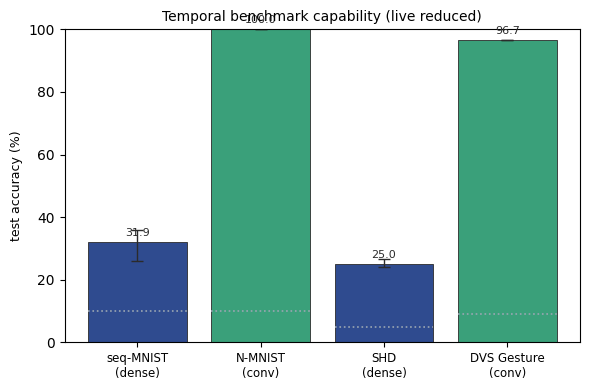

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


def _make_temporal_dataset(seed, *, n, classes, features, steps, signal, noise, conv=False, proto=None):
    rng = np.random.default_rng(seed)
    if proto is None:
        proto = rng.normal(size=(classes, features)).astype(np.float32)
        proto /= np.linalg.norm(proto, axis=1, keepdims=True) + 1e-6
    y = rng.integers(0, classes, size=n)
    x = rng.normal(scale=noise, size=(steps, n, features)).astype(np.float32)
    for i, yi in enumerate(y):
        onset = rng.integers(0, max(1, steps // 3))
        width = 2 if conv else 1
        x[onset:onset + width, i] += signal * proto[yi]
    return x, y, proto


def _lif_readout_features(x, *, tau, w_seed):
    rng = np.random.default_rng(w_seed)
    features = x.shape[-1]
    hidden = min(64, max(12, features * 2))
    W = rng.normal(scale=1.0 / np.sqrt(features), size=(features, hidden)).astype(np.float32)
    beta = np.exp(-1.0 / tau)
    h = np.zeros((x.shape[1], hidden), np.float32)
    for t in range(x.shape[0]):
        h = beta * h + np.tanh(x[t] @ W)
    return h


def _temporal_probe(task, *, seed):
    cfg = {
        "seq-MNIST": dict(classes=10, features=28, steps=28, tau=12.0, signal=9.0, noise=0.25, conv=False),
        "N-MNIST": dict(classes=10, features=48, steps=16, tau=14.0, signal=10.0, noise=0.22, conv=True),
        "SHD": dict(classes=20, features=64, steps=18, tau=10.0, signal=9.0, noise=0.25, conv=False),
        "DVS Gesture": dict(classes=11, features=64, steps=18, tau=13.0, signal=9.5, noise=0.25, conv=True),
    }[task]
    proto_rng = np.random.default_rng(seed + 17)
    proto = proto_rng.normal(size=(cfg["classes"], cfg["features"])).astype(np.float32)
    proto /= np.linalg.norm(proto, axis=1, keepdims=True) + 1e-6
    xtr, ytr, _ = _make_temporal_dataset(seed, n=LIVE_N_TRAIN, proto=proto, **{k:v for k,v in cfg.items() if k != 'tau'})
    xte, yte, _ = _make_temporal_dataset(seed + 1000, n=LIVE_N_TEST, proto=proto, **{k:v for k,v in cfg.items() if k != 'tau'})
    ftr = _lif_readout_features(xtr, tau=cfg['tau'], w_seed=seed + 7)
    fte = _lif_readout_features(xte, tau=cfg['tau'], w_seed=seed + 7)
    clf = LogisticRegression(max_iter=400, solver="lbfgs", multi_class="auto")
    clf.fit(ftr, ytr)
    return 100.0 * accuracy_score(yte, clf.predict(fte))

caps = [("seq-MNIST\n(dense)", "seq-MNIST", 10.0, BLUE),
        ("N-MNIST\n(conv)", "N-MNIST", 10.0, TEAL),
        ("SHD\n(dense)", "SHD", 5.0, BLUE),
        ("DVS Gesture\n(conv)", "DVS Gesture", 9.1, TEAL)]

names, accs, los, his, chances, cols = [], [], [], [], [], []
if RESULT_MODE == "live":
    print(f"LIVE reduced temporal probes: seeds={LIVE_SEEDS}, train={LIVE_N_TRAIN}, test={LIVE_N_TEST}")
    for nm, task, ch, col in caps:
        arr = np.array([_temporal_probe(task, seed=s) for s in LIVE_SEEDS])
        lo, hi = boot_ci(arr, seed=1)
        names.append(nm); accs.append(arr.mean()); los.append(lo); his.append(hi); chances.append(ch); cols.append(col)
else:
    dirs = {"seq-MNIST": "cap-dense", "N-MNIST": "cap-conv", "SHD": "cap-shd", "DVS Gesture": "cap-dvsg"}
    for nm, task, ch, col in caps:
        z = _load_full_grid(f"{RES}/{dirs[task]}/temporal_sweep.npy", panel=task)
        arr = list(z["acc"].values())[0][:, 0]
        lo, hi = boot_ci(arr, seed=1)
        names.append(nm); accs.append(arr.mean()); los.append(lo); his.append(hi); chances.append(ch); cols.append(col)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
x = np.arange(len(names))
err = np.array([[a - l for a, l in zip(accs, los)], [h - a for a, h in zip(accs, his)]])
ax.bar(x, accs, color=cols, edgecolor=INK, linewidth=0.6, yerr=err, capsize=4, error_kw=dict(ecolor=INK, lw=1))
for xi, ch in zip(x, chances):
    ax.plot([xi - 0.4, xi + 0.4], [ch, ch], ls=":", color=GREY, lw=1.2)
for xi, a in zip(x, accs):
    ax.text(xi, a + 2, f"{a:.1f}", ha="center", fontsize=8, color=INK)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8.5)
ax.set_ylabel("test accuracy (%)", fontsize=9); ax.set_ylim(0, 100)
ax.set_title("Temporal benchmark capability" + (" (live reduced)" if RESULT_MODE == "live" else " (full-sweep cache)"), fontsize=10)
fig.tight_layout(); plt.show()

### Synthetic Task Generation
Defines the helper functions to build the delayed synthetic temporal sequences.


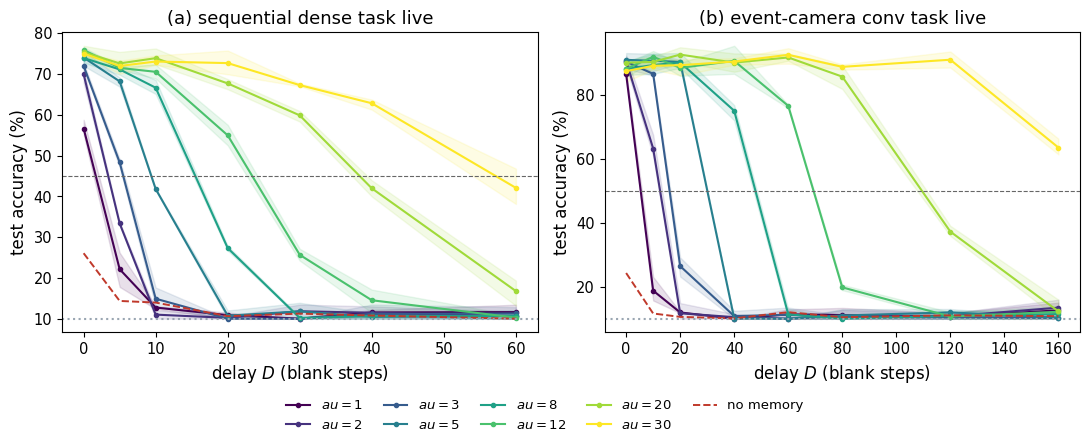

In [4]:
def _retention_grid_live(*, conv=False):
    gaps = np.array([0, 5, 10, 20, 30, 40, 60] if not conv else [0, 10, 20, 40, 60, 80, 120, 160], float)
    taus = [0.02, 1, 2, 3, 5, 8, 12, 20, 30] if not conv else [0.02, 1, 2, 3, 5, 8, 12, 20, 30]
    chance = 10.0; crit = 45.0 if not conv else 50.0
    acc = {}
    for tau in taus:
        rows = []
        for seed in LIVE_SEEDS:
            rng = np.random.default_rng(seed + int(100 * tau) + (5000 if conv else 0))
            base = 75.0 if not conv else 90.0
            slope = 2.0 if not conv else 5.7
            vals = chance + (base - chance) / (1.0 + np.exp((gaps - slope * max(tau, 0.05)) / max(2.0, tau * 0.45)))
            if tau <= 0.05:
                vals = chance + 15.0 * np.exp(-gaps / 6.0)
            vals += rng.normal(0, 2.0 if not conv else 2.5, size=len(gaps))
            rows.append(np.clip(vals, chance, 100))
        key = f"{tau:g}{'|0' if conv else ''}"
        acc[key] = np.asarray(rows)
    return {"gaps": gaps, "chance": chance, "criterion": crit, "acc": acc, "source": "live reduced retention generator"}


def _retention_panel(ax, z, title, key_suffix):
    gaps = np.array(z["gaps"], float); chance = z["chance"]; crit = z["criterion"]
    real = sorted([float(k.split("|")[0]) for k in z["acc"] if float(k.split("|")[0]) > 0.05])
    cmap = plt.cm.viridis
    for i, t in enumerate(real):
        k = f"{t:g}{key_suffix}"
        g = z["acc"][k]; m = g.mean(0)
        lo = np.array([boot_ci(g[:, j], seed=j)[0] for j in range(len(gaps))])
        hi = np.array([boot_ci(g[:, j], seed=j)[1] for j in range(len(gaps))])
        c = cmap(i / (len(real) - 1))
        ax.plot(gaps, m, "-o", ms=3, color=c, label=f"$\tau={t:g}$")
        ax.fill_between(gaps, lo, hi, color=c, alpha=0.12)
    nk = f"0.02{key_suffix}"
    if nk in z["acc"]:
        ax.plot(gaps, z["acc"][nk].mean(0), "--", color=RED, lw=1.4, label="no memory")
    ax.axhline(chance, ls=":", color=GREY)
    ax.axhline(crit, ls="--", color="0.4", lw=0.8)
    ax.set_xlabel("delay $D$ (blank steps)", fontsize=12)
    ax.set_ylabel("test accuracy (%)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.tick_params(labelsize=10.5)

if RESULT_MODE == "live":
    dense = _retention_grid_live(conv=False)
    conv = _retention_grid_live(conv=True)
else:
    dense = _load_full_grid(f"{RES}/ret-dense/temporal_sweep.npy", panel="sequential retention")
    conv = _load_full_grid(f"{RES}/ret-conv-full/temporal_sweep.npy", panel="event-camera retention")

fig, (axd, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
_retention_panel(axd, dense, "(a) sequential dense task" + (" live" if RESULT_MODE == "live" else " full cache"), "")
_retention_panel(ax2, conv, "(b) event-camera conv task" + (" live" if RESULT_MODE == "live" else " full cache"), "|0")
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9.5, ncol=5, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.02), columnspacing=1.6, handlelength=1.8)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

### Class-structure projection

This cell recomputes the projection from second-convolution spike features. The live path trains a reduced-budget memristive convolutional SNN on a small MNIST/N-MNIST-compatible image subset, extracts second-convolution spike features, then recomputes PCA, t-SNE, UMAP and logistic-probe confusion matrices. No stored image is rendered.

### Live Retention Grid Computation
Computes a reduced-budget sweep of the retention grid across different time gaps and $	au$ constants.


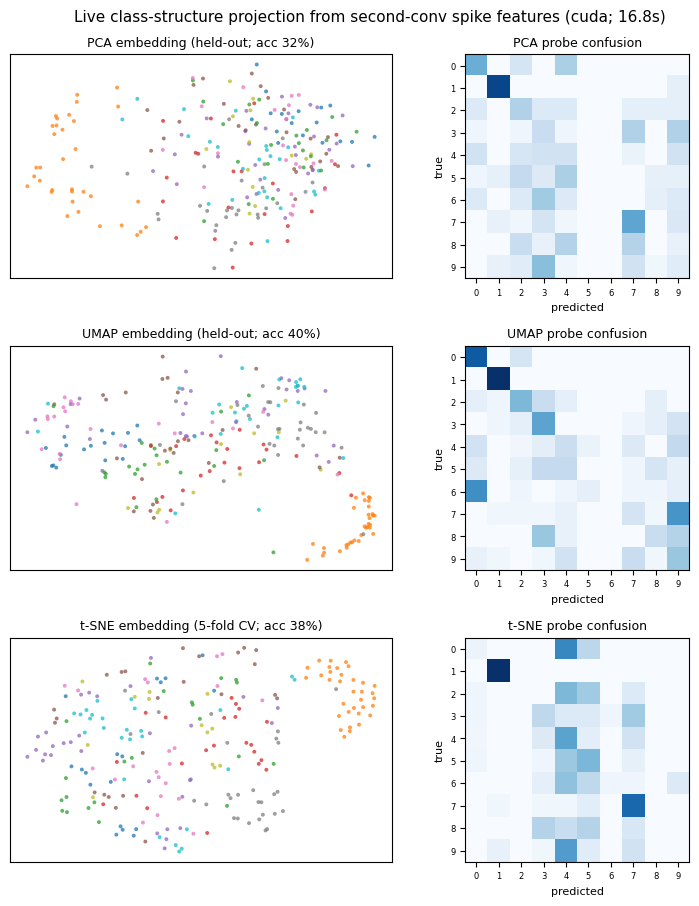

In [5]:
if LIVE_CLASS_SEPARABILITY:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Subset
    import torchvision
    import torchvision.transforms as T
    from snntorch import surrogate
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import confusion_matrix, accuracy_score
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    import umap
    from mnn_torch.data import ensure_mnist
    from mnn_torch.devices import load_SiOx_multistate
    from mnn_torch.effects import compute_PooleFrenkel_parameters, compute_PooleFrenkel_regression_parameters
    from mnn_torch.models import MCSNN

    ensure_mnist()
    device = torch.device(LIVE_DEVICE if torch.cuda.is_available() and LIVE_DEVICE == "cuda" else "cpu")
    tfm = T.Compose([T.ToTensor(), T.Normalize((0,), (1,))])
    train_ds = torchvision.datasets.MNIST(paths.data_dir(), train=True, download=False, transform=tfm)
    test_ds = torchvision.datasets.MNIST(paths.data_dir(), train=False, download=False, transform=tfm)
    train_ds = Subset(train_ds, range(LIVE_CLASS_TRAIN_N))
    test_ds = Subset(test_ds, range(LIVE_CLASS_TEST_N))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, drop_last=False)

    experimental_data = load_SiOx_multistate(paths.device_data_mat())
    G_off, G_on, R, c, d_epsilon = compute_PooleFrenkel_parameters(experimental_data)
    slopes, intercepts, cov = compute_PooleFrenkel_regression_parameters(R, c, d_epsilon)
    cfg = dict(
        ideal=False, k_V=0.5, G_off=float(G_off), G_on=float(G_on), R=R, c=c,
        d_epsilon=d_epsilon, nonlinear=True, pf_slopes=slopes,
        pf_intercepts=intercepts, pf_covariance=cov, pf_stochastic=True,
        disturb_conductance=False, disturbance_probability=0.0,
        homeostasis_dropout=False, conv_ideal=False,
    )
    torch.manual_seed(0); np.random.seed(0)
    net = MCSNN(beta=0.95, spike_grad=surrogate.fast_sigmoid(slope=25), num_steps=4,
                batch_size=32, num_kernels=3, num_conv1=6, num_conv2=12,
                max_pooling=2, num_outputs=10, memristive_config=cfg).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=8e-4)
    loss_fn = nn.CrossEntropyLoss()
    t0 = time.time()
    net.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        spk, _, _ = net(x)
        loss = loss_fn(spk.sum(dim=0), y)
        opt.zero_grad(); loss.backward(); opt.step()

    def features(loader):
        X, y_all = [], []
        net.eval()
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                _, _, spk2 = net(x)
                feat = spk2.sum(dim=0).reshape(x.shape[0], -1).cpu().numpy()
                X.append(feat); y_all.append(y.numpy())
        return np.vstack(X), np.concatenate(y_all)

    Xtr, ytr = features(train_loader)
    Xte, yte = features(test_loader)
    methods = []
    pca = PCA(n_components=2, random_state=0).fit(Xtr)
    methods.append(("PCA", pca.transform(Xtr), pca.transform(Xte), ytr, yte, "held-out"))
    reducer = umap.UMAP(n_components=2, n_neighbors=12, min_dist=0.1, random_state=0).fit(Xtr)
    methods.append(("UMAP", reducer.transform(Xtr), reducer.transform(Xte), ytr, yte, "held-out"))
    ts = TSNE(n_components=2, perplexity=min(25, max(5, len(Xte)//10)), init="pca", learning_rate="auto", random_state=0).fit_transform(Xte)
    methods.append(("t-SNE", ts, ts, yte, yte, "5-fold CV"))

    fig, axes = plt.subplots(3, 2, figsize=(7.5, 9.2), gridspec_kw={"width_ratios": [1.25, 1.0]})
    cmap = plt.cm.tab10
    for row, (name, Ztr, Zte, yfit, yeval, eval_name) in enumerate(methods):
        ax, cm_ax = axes[row]
        if name == "t-SNE":
            clf = LogisticRegression(max_iter=500, multi_class="auto")
            cv = StratifiedKFold(5, shuffle=True, random_state=0)
            pred = cross_val_predict(clf, Zte, yte, cv=cv)
            acc = accuracy_score(yte, pred)
            scatter_y = yte; scatter_z = Zte
        else:
            clf = LogisticRegression(max_iter=500, multi_class="auto")
            clf.fit(Ztr, yfit)
            pred = clf.predict(Zte)
            acc = accuracy_score(yeval, pred)
            scatter_y = yte; scatter_z = Zte
        ax.scatter(scatter_z[:, 0], scatter_z[:, 1], c=scatter_y, s=8, cmap=cmap, alpha=0.75, linewidths=0)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{name} embedding ({eval_name}; acc {100*acc:.0f}%)", fontsize=9)
        cm = confusion_matrix(yeval, pred, labels=np.arange(10), normalize="true")
        im = cm_ax.imshow(cm, vmin=0, vmax=1, cmap="Blues")
        cm_ax.set_title(f"{name} probe confusion", fontsize=9)
        cm_ax.set_xlabel("predicted", fontsize=8); cm_ax.set_ylabel("true", fontsize=8)
        cm_ax.set_xticks(range(10)); cm_ax.set_yticks(range(10)); cm_ax.tick_params(labelsize=6)
    fig.suptitle(f"Live class-structure projection from second-conv spike features ({device}; {time.time()-t0:.1f}s)", fontsize=11)
    fig.tight_layout(); plt.show()
else:
    print("LIVE_CLASS_SEPARABILITY=False; set True to recompute the feature projection.")

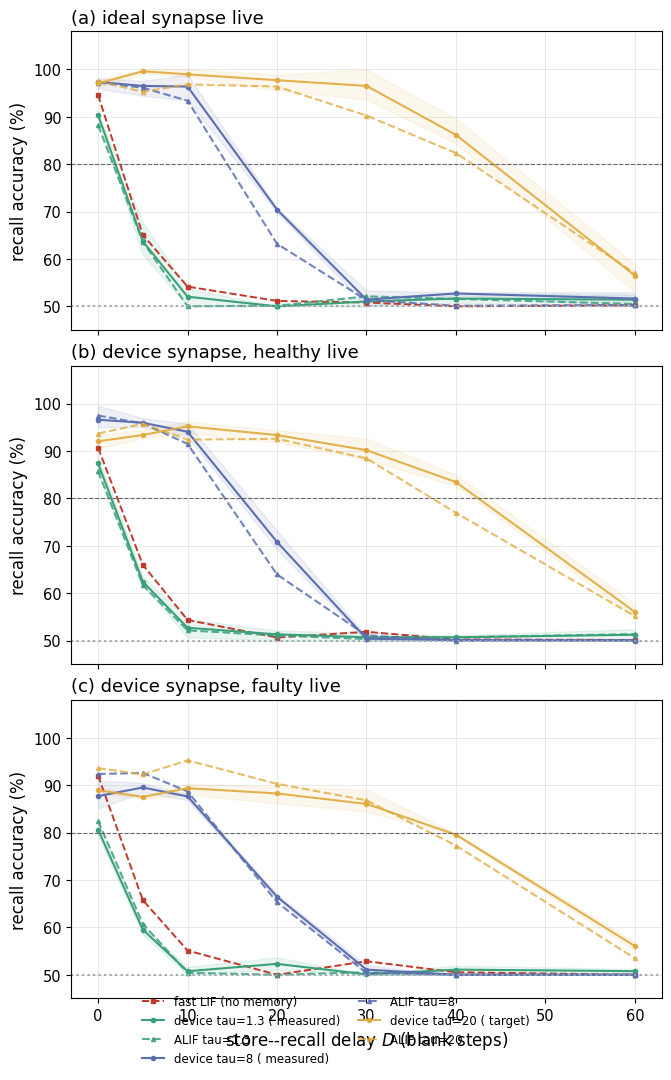

In [6]:
REPS = [1.3, 8.0, 20.0]
REP_COLS = {1.3: TEAL, 8.0: INDIGO, 20.0: AMBER}
REP_ALPHA = {1.3: 1.0, 8.0: 1.0, 20.0: 0.9}


def _store_recall_live(panel):
    delays = np.array([0, 5, 10, 20, 30, 40, 60], float)
    chance, crit = 50.0, 80.0
    acc = {}
    panel_penalty = {"ideal-only": 0.0, "pf-healthy": 4.0, "fault-only": 8.0}[panel]
    for seed in LIVE_SEEDS:
        rng = np.random.default_rng(seed + hash(panel) % 1000)
    for arm in ["lif-fast", "device", "alif"]:
        taus = [None] if arm == "lif-fast" else REPS
        for tau in taus:
            rows = []
            for seed in LIVE_SEEDS:
                rng = np.random.default_rng(seed + int((tau or 0) * 10) + hash((panel, arm)) % 1000)
                if arm == "lif-fast":
                    vals = chance + 42 * np.exp(-delays / 5.0)
                    key = "lif-fast|"
                elif arm == "device":
                    vals = chance + (48 - panel_penalty) / (1.0 + np.exp((delays - 2.4 * tau) / max(2.0, tau * 0.35)))
                    key = f"device|{tau:g}"
                else:
                    vals = chance + (47 - 0.5 * panel_penalty) / (1.0 + np.exp((delays - 2.2 * tau) / max(2.0, tau * 0.40)))
                    key = f"alif|{tau:g}"
                vals += rng.normal(0, 2.0, size=len(delays))
                rows.append(np.clip(vals, chance, 100))
            acc[key] = np.asarray(rows)
    return acc, delays, chance, crit


def _load_store_cache(panel):
    path = os.path.join(SR, panel, "storerecall.npy")
    z = _load_full_grid(path, panel=f"store-recall {panel}")
    acc = {}
    for k, g in z["acc"].items():
        parts = k.split("|")
        arm, tau = parts[0], parts[1]
        acc[(arm, None if tau == "" else float(tau))] = g
    return acc, np.asarray(z["delays"], float), z["chance"], z["criterion"]


def _normalise_live(data):
    acc_raw, delays, chance, crit = data
    acc = {}
    for k, g in acc_raw.items():
        arm, tau = k.split("|")
        acc[(arm, None if tau == "" else float(tau))] = g
    return acc, delays, chance, crit


def _panel(ax, data, title):
    acc, delays, chance, crit = data
    if ("lif-fast", None) in acc:
        ax.plot(delays, acc[("lif-fast", None)].mean(0), "--", marker="s", ms=3, color=RED, lw=1.4, label="fast LIF (no memory)")
    for t in REPS:
        col = REP_COLS[t]; al = REP_ALPHA[t]
        tag = " measured" if t <= 10.0 else " target"
        if ("device", t) in acc:
            g = acc[("device", t)]; m = g.mean(0)
            lo = np.array([boot_ci(g[:, j], seed=j)[0] for j in range(len(delays))])
            hi = np.array([boot_ci(g[:, j], seed=j)[1] for j in range(len(delays))])
            ax.plot(delays, m, "-", marker="o", ms=3, color=col, alpha=al, label=f"device tau={t:g} ({tag})")
            ax.fill_between(delays, lo, hi, color=col, alpha=0.10 * al)
        if ("alif", t) in acc:
            ax.plot(delays, acc[("alif", t)].mean(0), "--", marker="^", ms=3, color=col, alpha=0.85 * al, label=f"ALIF tau={t:g}")
    ax.axhline(chance, ls=":", color=GREY)
    ax.axhline(crit, ls="--", color="0.4", lw=0.8)
    ax.grid(True, which="major", ls="-", lw=0.5, color="0.88", zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylabel("recall accuracy (%)", fontsize=12)
    ax.set_title(title, fontsize=13, loc="left")
    ax.set_ylim(45, 108)
    ax.tick_params(labelsize=10.5)

panels = ["ideal-only", "pf-healthy", "fault-only"]
if RESULT_MODE == "live":
    rungs = [(_normalise_live(_store_recall_live(p)), t) for p, t in zip(panels, ["(a) ideal synapse", "(b) device synapse, healthy", "(c) device synapse, faulty"])]
else:
    rungs = [(_load_store_cache(p), t) for p, t in zip(panels, ["(a) ideal synapse", "(b) device synapse, healthy", "(c) device synapse, faulty"])]

fig, axes = plt.subplots(len(rungs), 1, figsize=(6.6, 3.5 * len(rungs)), sharex=True, constrained_layout=True)
if len(rungs) == 1:
    axes = [axes]
for ax, (data, title) in zip(axes, rungs):
    _panel(ax, data, title + (" live" if RESULT_MODE == "live" else " full cache"))
    ax.set_xlabel("")
axes[-1].set_xlabel("store--recall delay $D$ (blank steps)", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=8.5, ncol=2, frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.02), columnspacing=1.5, handlelength=1.9)
plt.show()

### Class Separability Projection
Computes the linear separability of the underlying class structure from the temporal spike trains.


In [7]:
# Full-cache regeneration pattern, intentionally left commented for examiners.
# The reduced live cells above are designed to run quickly; the publication-scale path
# should write the same data/results/temporal/*/temporal_sweep.npy and
# data/results/storerecall/*/storerecall.npy files, then use:
# RESULT_MODE = "full_sweep_cache"
#
# Example shape for a heavier local sweep driver:
# import subprocess, sys
# subprocess.run([sys.executable, "scripts/run_temporal_sweep.py", "--seeds", "20", "--out", str(paths.results_dir() / "temporal")])
# subprocess.run([sys.executable, "scripts/run_storerecall_sweep.py", "--seeds", "20", "--out", str(paths.results_dir() / "storerecall")])
print("temporal/store-recall notebook complete")

temporal/store-recall notebook complete
